# Student Performance Prediction System

## Machine Learning Internship Project

### Infobharat Interns (IBI)

### Objective
Predict student final exam scores using Machine Learning based on attendance, study habits, academic performance, and extracurricular activities.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


## 1. Load Dataset

In [46]:
df = pd.read_csv("cleaned_student_performance_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 2. Dataset Preview

In [47]:
df.head()

,StudentID,Age,Gender,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,ExtracurricularActivities,InternetAccessAtHome,ParentEducationLevel,FinalExamScore
0,1,24,Male,70,25,60,76,9,No,Yes,High School,99.33
1,2,21,Male,77,10,88,92,5,No,No,Graduate,91.52
2,3,22,Female,89,7,86,64,6,No,Yes,Postgraduate,77.66
3,4,24,Female,50,22,45,59,3,No,No,Postgraduate,70.58
4,5,20,Female,85,17,87,97,10,No,No,High School,100.00


## 3. Dataset Information

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  2500 non-null   int64  
 1   Age                        2500 non-null   int64  
 2   Gender                     2500 non-null   object 
 3   AttendancePercentage       2500 non-null   int64  
 4   StudyHoursPerWeek          2500 non-null   int64  
 5   AssignmentCompletionRate   2500 non-null   int64  
 6   PreviousExamScore          2500 non-null   int64  
 7   ParticipationScore         2500 non-null   int64  
 8   ExtracurricularActivities  2500 non-null   object 
 9   InternetAccessAtHome       2500 non-null   object 
 10  ParentEducationLevel       2500 non-null   object 
 11  FinalExamScore             2500 non-null   float64
dtypes: float64(1), int64(7), object(4)
memory usage: 234.5+ KB


## 4. Check Missing Values

In [49]:
df.isnull().sum()

StudentID                    0
Age                          0
Gender                       0
AttendancePercentage         0
StudyHoursPerWeek            0
AssignmentCompletionRate     0
PreviousExamScore            0
ParticipationScore           0
ExtracurricularActivities    0
InternetAccessAtHome         0
ParentEducationLevel         0
FinalExamScore               0
dtype: int64

## 5. Data Preprocessing

In [50]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df["ExtracurricularActivities"] = encoder.fit_transform(
    df["ExtracurricularActivities"]
)

df["InternetAccessAtHome"] = encoder.fit_transform(
    df["InternetAccessAtHome"]
)

df["ParentEducationLevel"] = encoder.fit_transform(
    df["ParentEducationLevel"]
)

print("Encoding Completed")

Encoding Completed


## 6. Verify Encoded Dataset

In [51]:
df.head()

,StudentID,Age,Gender,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,ExtracurricularActivities,InternetAccessAtHome,ParentEducationLevel,FinalExamScore
0,1,24,1,70,25,60,76,9,0,1,1,99.33
1,2,21,1,77,10,88,92,5,0,0,0,91.52
2,3,22,0,89,7,86,64,6,0,1,2,77.66
3,4,24,0,50,22,45,59,3,0,0,2,70.58
4,5,20,0,85,17,87,97,10,0,0,1,100.00


## 7. Feature Selection

In [52]:
X = df.drop(
    ["StudentID", "FinalExamScore"],
    axis=1
)

y = df["FinalExamScore"]

print("Features and Target Created")

Features and Target Created


In [53]:
X.head()

,Age,Gender,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,ExtracurricularActivities,InternetAccessAtHome,ParentEducationLevel
0,24,1,70,25,60,76,9,0,1,1
1,21,1,77,10,88,92,5,0,0,0
2,22,0,89,7,86,64,6,0,1,2
3,24,0,50,22,45,59,3,0,0,2
4,20,0,85,17,87,97,10,0,0,1


## 8. Train Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (2000, 10)
Testing Shape : (500, 10)


## 9. Model Training

In [55]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


## 10. Prediction on Test Data

## 11. Model Evaluation

In [56]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Model Performance")
print("MAE =", round(mae, 4))
print("MSE =", round(mse, 4))
print("RMSE =", round(rmse, 4))
print("R2 Score =", round(r2, 4))

Model Performance
MAE = 3.746
MSE = 23.0145
RMSE = 4.7973
R2 Score = 0.8794


## 12. Save Trained Model

In [57]:
joblib.dump(
    model,
    "student_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## 13. Correlation Heatmap

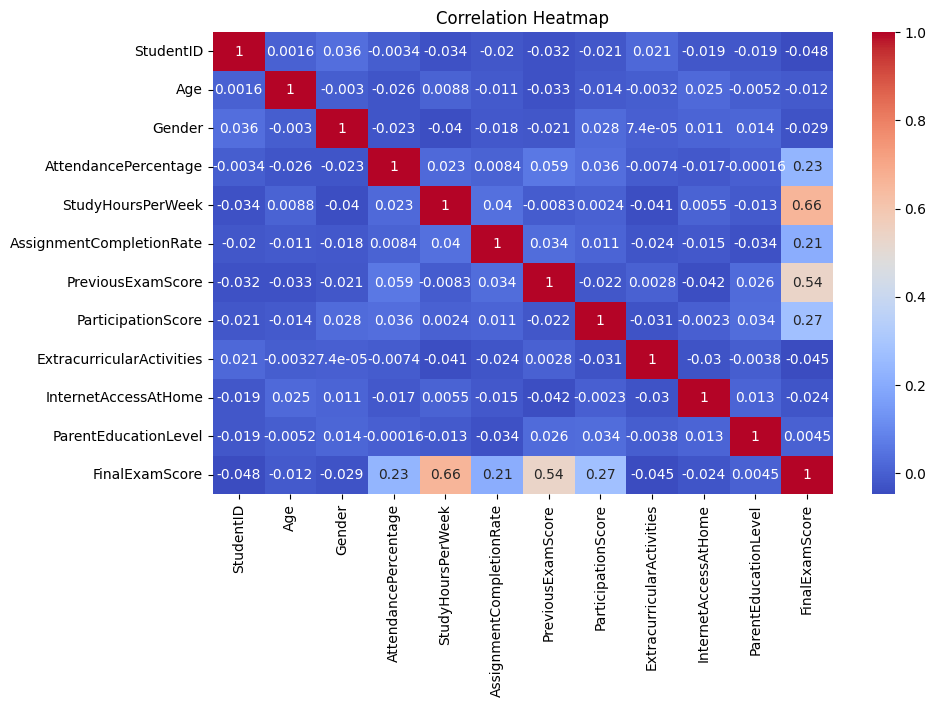

In [58]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## 14 Study Hours vs Final Score

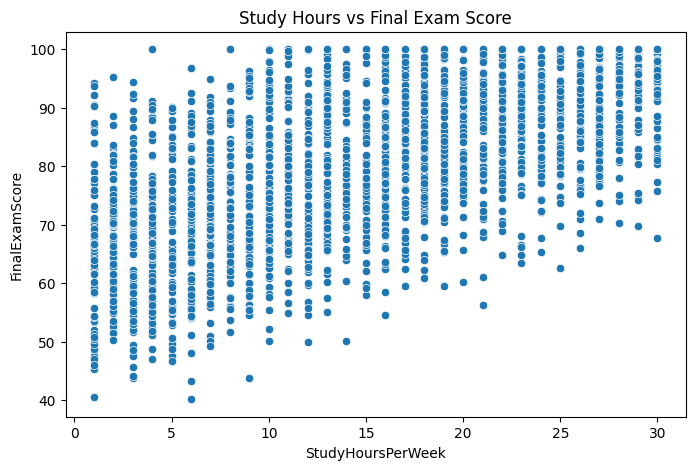

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["StudyHoursPerWeek"],
    y=df["FinalExamScore"]
)
plt.title("Study Hours vs Final Exam Score")
plt.show()

## 15. Final Score Distribution

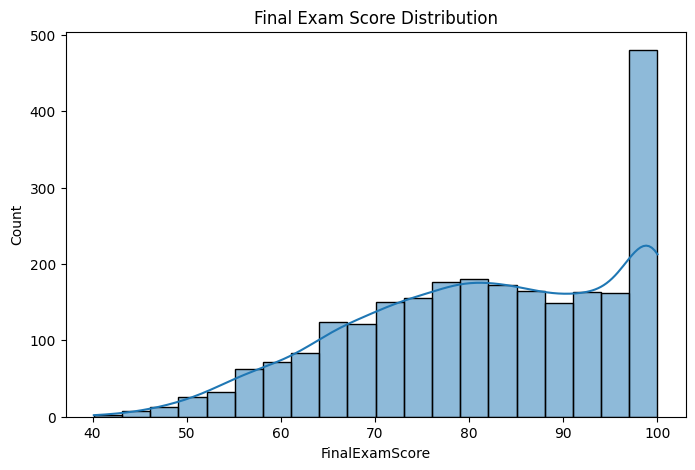

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["FinalExamScore"],
    bins=20,
    kde=True
)

plt.title("Final Exam Score Distribution")
plt.show()

## 16.Attendance vs Final Score

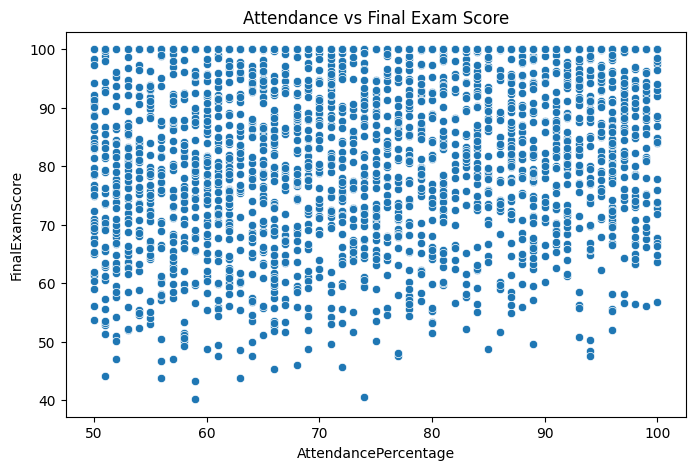

In [61]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["AttendancePercentage"],
    y=df["FinalExamScore"]
)
plt.title("Attendance vs Final Exam Score")
plt.show()

## 17.Parent Education Level Distribution (Pie Chart)

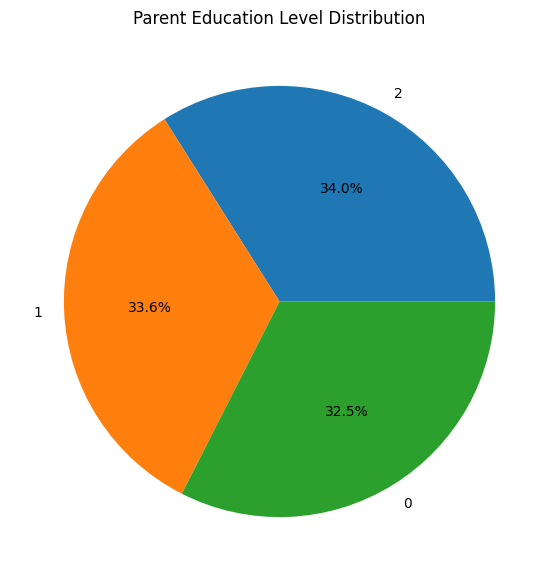

In [62]:
plt.figure(figsize=(7,7))

df["ParentEducationLevel"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Parent Education Level Distribution")
plt.ylabel("")
plt.show()

### Conclusion

The Student Performance Prediction System successfully predicts student final exam scores using Machine Learning.

Project Steps:

- Data Loading
- Data Cleaning
- Data Preprocessing
- Feature Selection
- Train-Test Split
- Model Training
- Prediction
- Model Evaluation
- Model Saving

The Linear Regression model achieved good predictive performance and can be used for educational analytics and student performance monitoring.

# Thank You

Student Performance Prediction System

Developed as part of Machine Learning Internship Project

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

Author: Bhavnesh Pathak